In [48]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 2. Load & Clean Data
df = pd.read_csv(r"C:\Users\91636\Downloads\Phishing_Email_Dataset.csv\Phishing_Email.csv")  # Adjust path as needed
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# 3. Preprocessing Text
def preprocess_text(text):
    import re
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Email Text"] = df["Email Text"].apply(preprocess_text)

# 4. Encode Labels
le = LabelEncoder()
df["Email Type"] = le.fit_transform(df["Email Type"])  # phishing=1, legit=0

# 5. Tokenize and Pad
tk = Tokenizer(num_words=10000, oov_token="<OOV>")
tk.fit_on_texts(df["Email Text"])

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tk, f)

X_seq = pad_sequences(tk.texts_to_sequences(df["Email Text"]), maxlen=150)

# 6. Split for ML models
X_train_seq, X_test_seq, y_train, y_test = train_test_split(X_seq, df["Email Type"], test_size=0.2, random_state=42)

# 7. Define and Train ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
}

print("\n=== Machine Learning Classifier Results ===\n")
for name, model in models.items():
    model.fit(X_train_seq, y_train)
    y_pred = model.predict(X_test_seq)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# 8. RNN Deep Learning Model
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=len(tk.word_index)+1, output_dim=50, input_length=150))
model_rnn.add(SimpleRNN(units=100))
model_rnn.add(Dropout(0.45))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.build(input_shape=(None, 150))  # Explicitly build
model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

# Train RNN
model_rnn.fit(X_train_seq, y_train, epochs=5, batch_size=32, validation_data=(X_test_seq, y_test))

# Evaluate RNN
y_pred_rnn = model_rnn.predict(X_test_seq)
y_pred_rnn = (y_pred_rnn > 0.5).astype(int)

print("\n=== Simple RNN Classifier Results ===\n")
print("Accuracy:", accuracy_score(y_test, y_pred_rnn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rnn))
print("Classification Report:\n", classification_report(y_test, y_pred_rnn))



=== Machine Learning Classifier Results ===

--- Logistic Regression ---
Accuracy: 0.6342903139254091
Confusion Matrix:
 [[ 518 1000]
 [ 363 1846]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.34      0.43      1518
           1       0.65      0.84      0.73      2209

    accuracy                           0.63      3727
   macro avg       0.62      0.59      0.58      3727
weighted avg       0.62      0.63      0.61      3727

--- Decision Tree ---
Accuracy: 0.7161255701636705
Confusion Matrix:
 [[1027  491]
 [ 567 1642]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.68      0.66      1518
           1       0.77      0.74      0.76      2209

    accuracy                           0.72      3727
   macro avg       0.71      0.71      0.71      3727
weighted avg       0.72      0.72      0.72      3727

--- Random Forest ---
Accuracy: 0.7756909042125033
C

C:\Users\91636\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 150, 50)             │       9,115,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 100)                 │          15,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,131,101 (34.83 MB)

 Trainable params: 9,131,101 (34.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.7008 - loss: 0.5531 - val_accuracy: 0.9270 - val_loss: 0.1992
Epoch 2/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.9425 - loss: 0.1585 - val_accuracy: 0.9037 - val_loss: 0.2142
Epoch 3/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9515 - loss: 0.1240 - val_accuracy: 0.9380 - val_loss: 0.1644
Epoch 4/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.9657 - loss: 0.0870 - val_accuracy: 0.8801 - val_loss: 0.3623
Epoch 5/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.9660 - loss: 0.0909 - val_accuracy: 0.9439 - val_loss: 0.1827
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

=== Simple RNN Classifier Results ===

Accuracy: 0.9439227260531259
Confusion Matrix:
 [[1445   73]
 [ 136 2073]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      1518
           1       0.97      0.94      0.95      2209

    accura

Epoch 1/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9026 - loss: 0.2313 - val_accuracy: 0.9439 - val_loss: 0.1679
Epoch 2/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9670 - loss: 0.0928 - val_accuracy: 0.9243 - val_loss: 0.2080
Epoch 3/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.9587 - loss: 0.1275 - val_accuracy: 0.9039 - val_loss: 0.2498
Epoch 4/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.8575 - loss: 0.3288 - val_accuracy: 0.9214 - val_loss: 0.2195
Epoch 5/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.9533 - loss: 0.1258 - val_accuracy: 0.8377 - val_loss: 0.7338
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


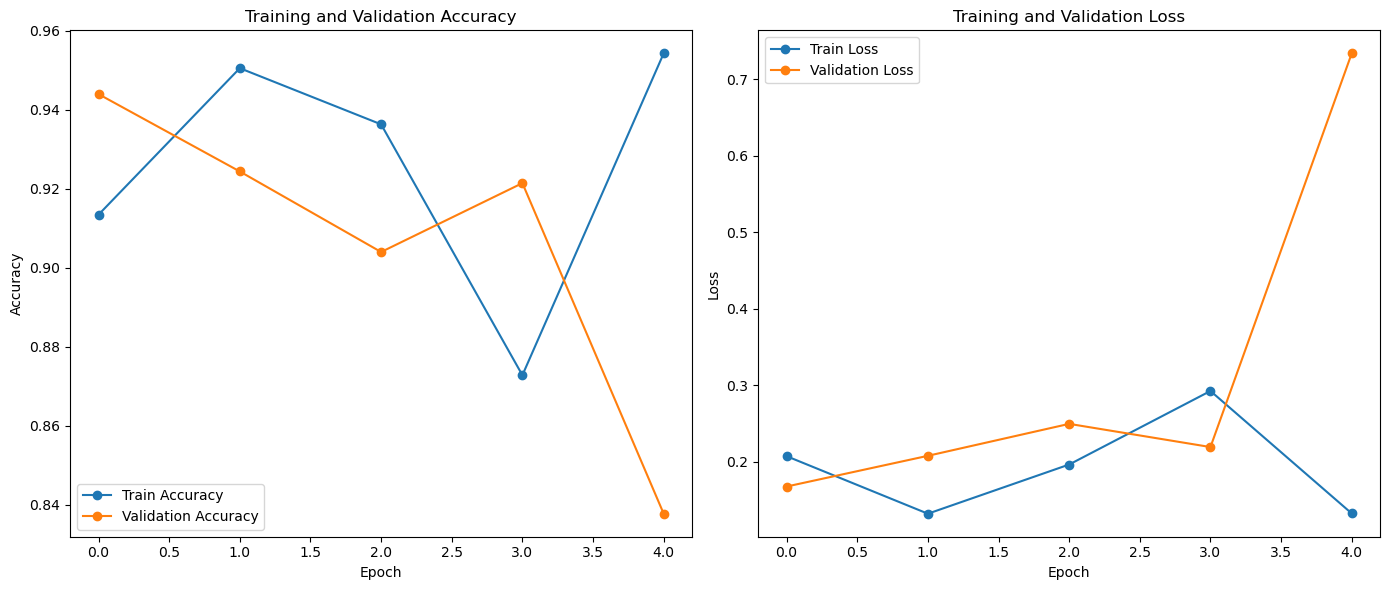

In [49]:
# Train the model and save the returned History object
history = model_rnn.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test))

# Now, access the keys from history.history
print(history.history.keys())

# Use 'history' for plotting
metrics = list(history.history.keys())
acc_key = 'accuracy' if 'accuracy' in metrics else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in metrics else 'val_acc'

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history[acc_key], label='Train Accuracy', marker='o')
plt.plot(history.history[val_acc_key], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


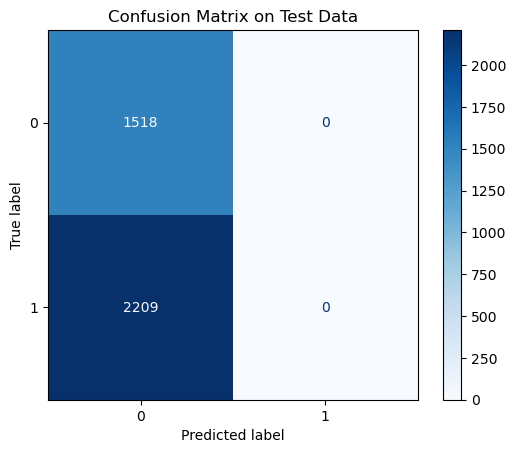

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.41      1.00      0.58      1518
     Class 1       0.00      0.00      0.00      2209

    accuracy                           0.41      3727
   macro avg       0.20      0.50      0.29      3727
weighted avg       0.17      0.41      0.24      3727



C:\Users\91636\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\91636\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\91636\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- Predict on test data ---
y_test_pred_probs = model_rnn.predict(X_test_seq)  # Use your test data variable
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# y_test is a pandas Series with integer labels, so use it directly
y_test_true = y_test.values  # convert Series to numpy array if needed

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Data")
plt.show()

# --- Classification Report ---
# Adjust class names exactly to number of unique classes (2 in your case)
class_names = ['Class 0', 'Class 1']  # update if you want better names

report = classification_report(y_test_true, y_test_pred, target_names=class_names)
print("Classification Report:\n", report)


In [54]:
model_rnn.save('model_rnn.h5')

